# Phase 1: Problem Definition & Data Exploration
**Course:** AIS431 - Intelligent Decision Support Systems  
**Dataset:** Credit Risk Dataset  
**Objective:** Predict loan default (`loan_status`)  

This notebook performs initial data inspection, quality assessment, and exploratory data analysis (EDA) on the credit risk dataset.

## 1. Load Libraries and Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Load the dataset
df = pd.read_csv('credit_risk_dataset.csv')

# Display the first few rows
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset Shape:", df.shape)

First 5 rows of the dataset:
   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y  

## 2. Initial Data Inspection

In [3]:
# Display data types and info
print("Data Types:")
print(df.dtypes)
print("\n" + "="*80)
print("Dataset Info:")
df.info()
print("\n" + "="*80)
print("Descriptive Statistics:")
print(df.describe())

Data Types:
person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  obj

## 3. Missing Values and Data Quality Checks

In [4]:
# Check for missing values
print("Missing Values:")
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_values, 'Percentage': missing_percent})
print(missing_df[missing_df['Missing_Count'] > 0])
print("\n" + "="*80)

# Check for duplicates
duplicate_count = df.duplicated().sum()
print(f"Number of Duplicate Rows: {duplicate_count}")
print(f"Percentage of Duplicates: {(duplicate_count / len(df)) * 100:.2f}%")
print("\n" + "="*80)

# Check age and employment length anomalies
print("Age Statistics:")
print(f"Min Age: {df['person_age'].min()}")
print(f"Max Age: {df['person_age'].max()}")
print(f"Mean Age: {df['person_age'].mean():.2f}")
print(f"Ages > 100: {(df['person_age'] > 100).sum()}")

print("\nEmployment Length Statistics:")
print(f"Min Employment Length: {df['person_emp_length'].min()}")
print(f"Max Employment Length: {df['person_emp_length'].max()}")
print(f"Mean Employment Length: {df['person_emp_length'].mean():.2f}")
print(f"Employment Length > 60: {(df['person_emp_length'] > 60).sum()}")
print(f"Employment Length > Age: {(df['person_emp_length'] > df['person_age']).sum()}")

Missing Values:
                   Missing_Count  Percentage
person_emp_length            895    2.747000
loan_int_rate               3116    9.563856

Number of Duplicate Rows: 165
Percentage of Duplicates: 0.51%

Age Statistics:
Min Age: 20
Max Age: 144
Mean Age: 27.73
Ages > 100: 5

Employment Length Statistics:
Min Employment Length: 0.0
Max Employment Length: 123.0
Mean Employment Length: 4.79
Employment Length > 60: 2
Employment Length > Age: 2


## 4. Data Cleaning: Handle Duplicates and Invalid Outliers

In [5]:
print(f"Original dataset shape: {df.shape}")

# Step 1: Remove duplicates
df_clean = df.drop_duplicates()
print(f"After removing duplicates: {df_clean.shape} (removed {df.shape[0] - df_clean.shape[0]} duplicates)")

# Step 2: Handle missing values using median imputation
print("\n" + "="*80)
print("Imputing Missing Values with Median:")
if df_clean['person_emp_length'].isnull().sum() > 0:
    median_emp_length = df_clean['person_emp_length'].median()
    df_clean['person_emp_length'].fillna(median_emp_length, inplace=True)
    print(f"  - person_emp_length: Imputed {df_clean['person_emp_length'].isnull().sum()} missing values with median = {median_emp_length}")

if df_clean['loan_int_rate'].isnull().sum() > 0:
    median_int_rate = df_clean['loan_int_rate'].median()
    df_clean['loan_int_rate'].fillna(median_int_rate, inplace=True)
    print(f"  - loan_int_rate: Imputed {df_clean['loan_int_rate'].isnull().sum()} missing values with median = {median_int_rate}")

# Step 3: Remove invalid age outliers (> 100 years)
print("\n" + "="*80)
print("Handling Age Outliers:")
print(f"  - Rows with age > 100 before removal: {(df_clean['person_age'] > 100).sum()}")
df_clean = df_clean[df_clean['person_age'] <= 100]
print(f"  - Rows with age > 100 after removal: {(df_clean['person_age'] > 100).sum()}")

# Step 4: Remove invalid employment length outliers
print("\n" + "="*80)
print("Handling Employment Length Outliers:")
print(f"  - Rows with employment length > 60 before removal: {(df_clean['person_emp_length'] > 60).sum()}")
df_clean = df_clean[df_clean['person_emp_length'] <= 60]
print(f"  - Rows with employment length > 60 after removal: {(df_clean['person_emp_length'] > 60).sum()}")

print(f"  - Rows with employment length > age before removal: {(df_clean['person_emp_length'] > df_clean['person_age']).sum()}")
df_clean = df_clean[df_clean['person_emp_length'] <= df_clean['person_age']]
print(f"  - Rows with employment length > age after removal: {(df_clean['person_emp_length'] > df_clean['person_age']).sum()}")

print("\n" + "="*80)
print(f"Final cleaned dataset shape: {df_clean.shape}")
print(f"Total rows removed: {df.shape[0] - df_clean.shape[0]}")

Original dataset shape: (32581, 12)
After removing duplicates: (32416, 12) (removed 165 duplicates)

Imputing Missing Values with Median:
  - person_emp_length: Imputed 0 missing values with median = 4.0
  - loan_int_rate: Imputed 0 missing values with median = 10.99

Handling Age Outliers:
  - Rows with age > 100 before removal: 5
  - Rows with age > 100 after removal: 0

Handling Employment Length Outliers:
  - Rows with employment length > 60 before removal: 2
  - Rows with employment length > 60 after removal: 0
  - Rows with employment length > age before removal: 0
  - Rows with employment length > age after removal: 0

Final cleaned dataset shape: (32409, 12)
Total rows removed: 172


## 5. Target Variable Distribution

Loan Status Distribution:
loan_status
0    25321
1     7088
Name: count, dtype: int64

Loan Status Percentage:
loan_status
0    78.129532
1    21.870468
Name: proportion, dtype: float64


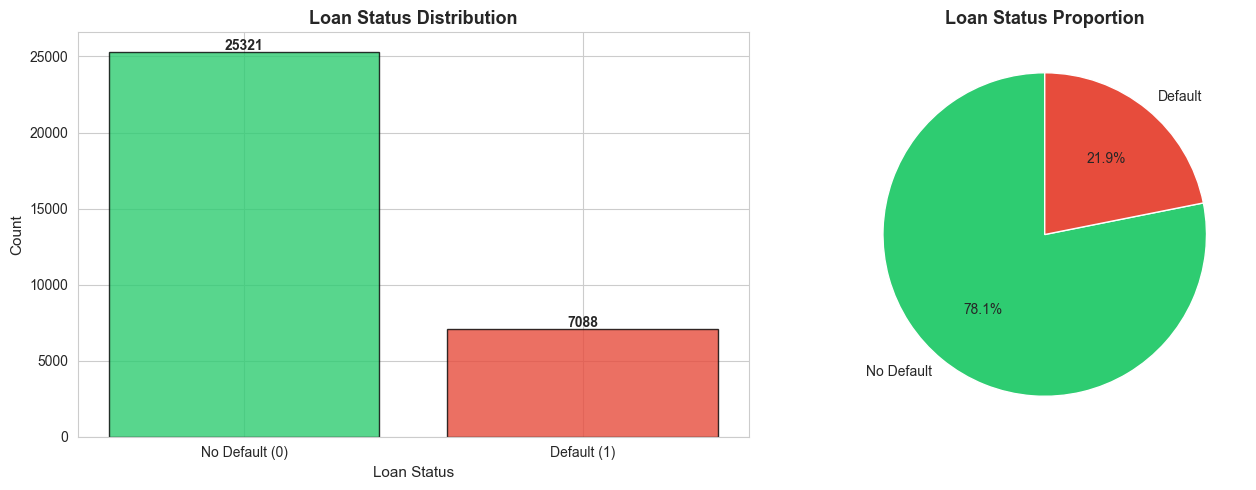


Class Imbalance: 21.87% of loans defaulted


In [6]:
# Check class distribution
print("Loan Status Distribution:")
print(df_clean['loan_status'].value_counts())
print("\nLoan Status Percentage:")
print(df_clean['loan_status'].value_counts(normalize=True) * 100)

# Plot target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
loan_status_counts = df_clean['loan_status'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['No Default (0)', 'Default (1)'], loan_status_counts.values, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_title('Loan Status Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xlabel('Loan Status', fontsize=11)
for i, v in enumerate(loan_status_counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
labels = ['No Default', 'Default']
axes[1].pie(loan_status_counts.values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Loan Status Proportion', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# Check for class imbalance
default_ratio = (df_clean['loan_status'] == 1).sum() / len(df_clean) * 100
print(f"\nClass Imbalance: {default_ratio:.2f}% of loans defaulted")

## 6. Numerical Feature Distributions

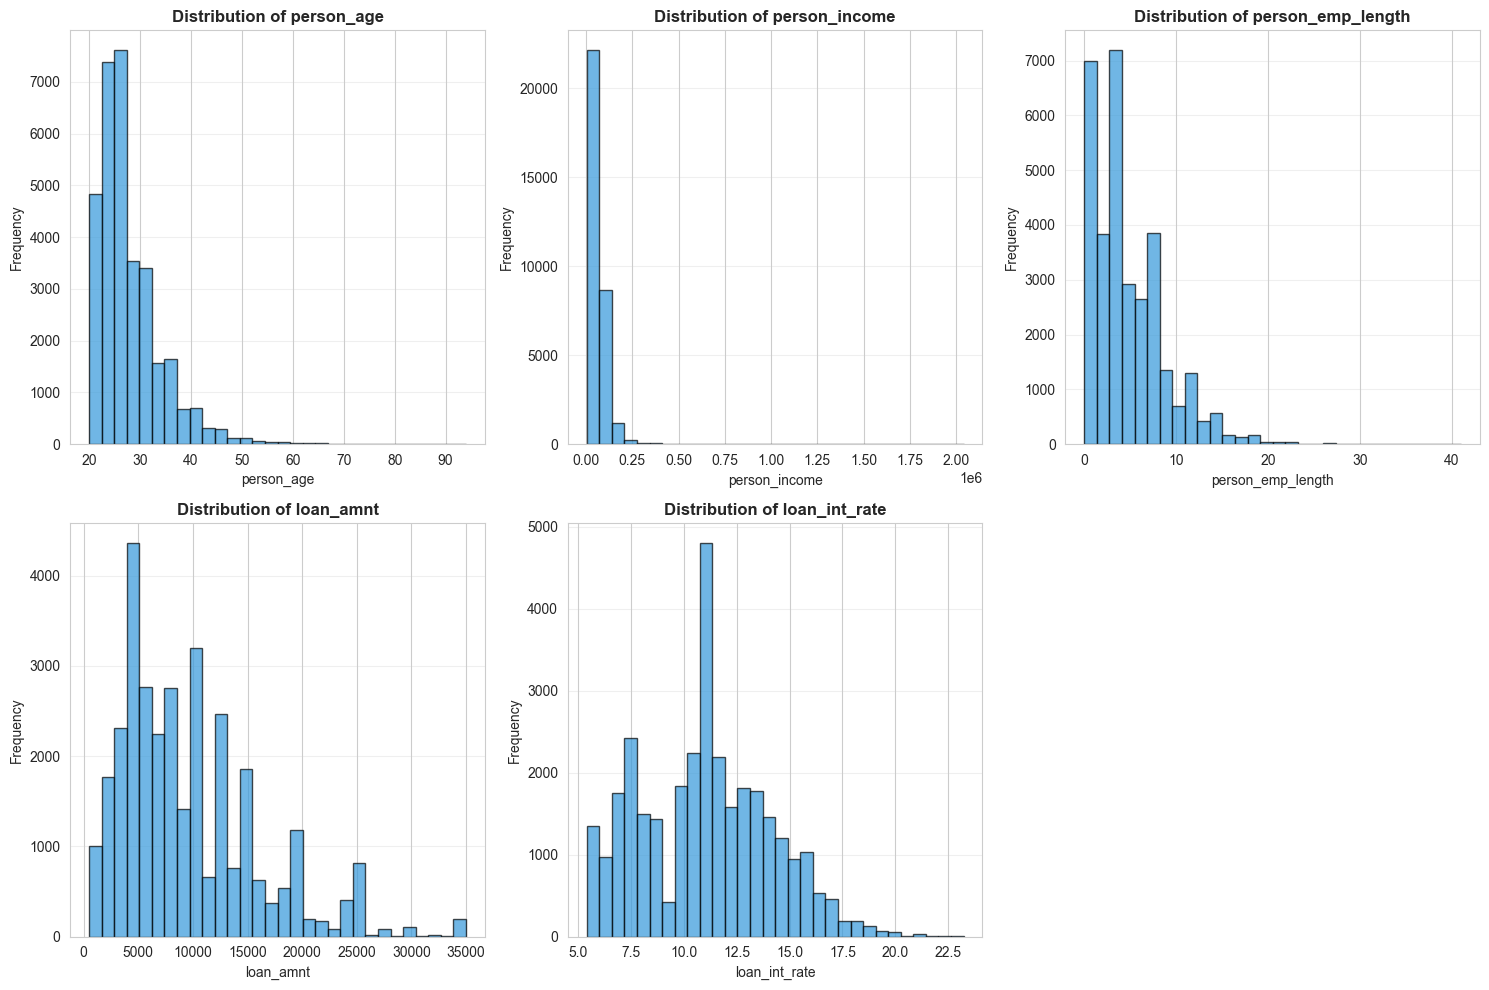

Summary Statistics for Numerical Features:
         person_age  person_income  person_emp_length     loan_amnt  \
count  32409.000000   3.240900e+04       32409.000000  32409.000000   
mean      27.730754   6.589428e+04           4.761424   9592.486655   
std        6.210445   5.251787e+04           3.983757   6320.885127   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12250.000000   
max       94.000000   2.039784e+06          41.000000  35000.000000   

       loan_int_rate  
count   32409.000000  
mean       11.014512  
std         3.083104  
min         5.420000  
25%         8.490000  
50%        10.990000  
75%        13.110000  
max        23.220000  


In [7]:
# Select key numerical features
numerical_features = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, feature in enumerate(numerical_features):
    axes[idx].hist(df_clean[feature], bins=30, color='#3498db', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(feature, fontsize=10)
    axes[idx].set_ylabel('Frequency', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)

# Remove the extra subplot
axes[5].remove()

plt.tight_layout()
plt.show()

# Display basic statistics
print("Summary Statistics for Numerical Features:")
print(df_clean[numerical_features].describe())

## 7. Key Feature vs. Default Analysis: The 3 Most Interesting Patterns

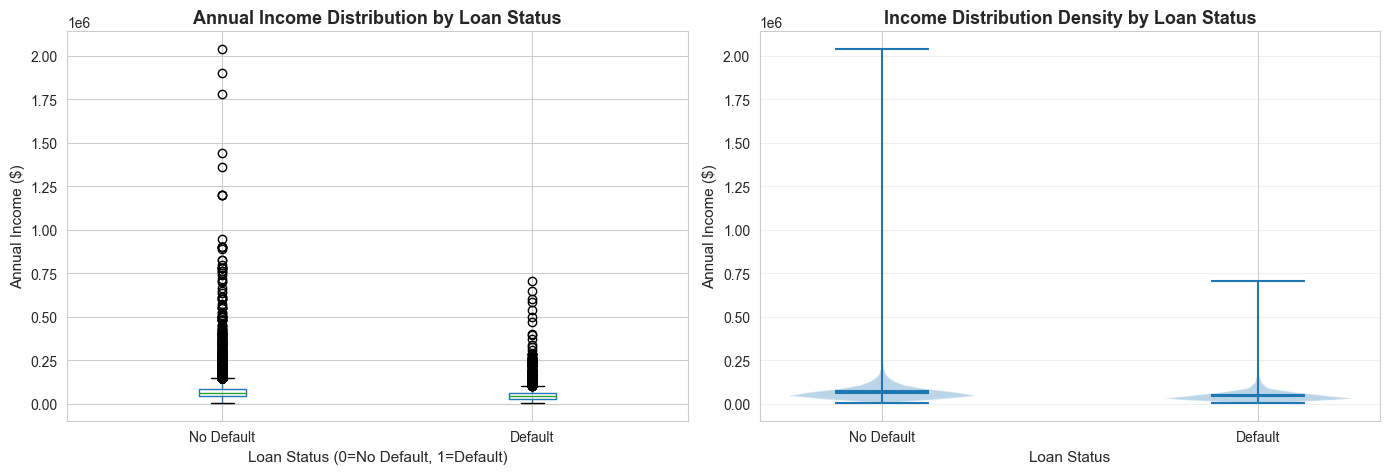

Income Statistics by Loan Status:
               count          mean           std     min      25%      50%  \
loan_status                                                                  
0            25321.0  70597.359070  55311.483970  7000.0  42000.0  60000.0   
1             7088.0  49093.100451  36344.725503  4000.0  30000.0  41655.0   

                 75%        max  
loan_status                      
0            84000.0  2039784.0  
1            59600.0   703800.0  


In [8]:
### Plot 1: Income as a Differentiator
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot for income by loan status
df_clean.boxplot(column='person_income', by='loan_status', ax=axes[0])
axes[0].set_title('Annual Income Distribution by Loan Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Status (0=No Default, 1=Default)', fontsize=11)
axes[0].set_ylabel('Annual Income ($)', fontsize=11)
plt.sca(axes[0])
plt.xticks([1, 2], ['No Default', 'Default'])

# Violin plot for more detailed distribution
parts = axes[1].violinplot(
    [df_clean[df_clean['loan_status'] == 0]['person_income'],
     df_clean[df_clean['loan_status'] == 1]['person_income']],
    positions=[0, 1],
    showmeans=True,
    showmedians=True
)
axes[1].set_title('Income Distribution Density by Loan Status', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Loan Status', fontsize=11)
axes[1].set_ylabel('Annual Income ($)', fontsize=11)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Default', 'Default'])
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

# Income statistics by default status
print("Income Statistics by Loan Status:")
income_stats = df_clean.groupby('loan_status')['person_income'].describe()
print(income_stats)

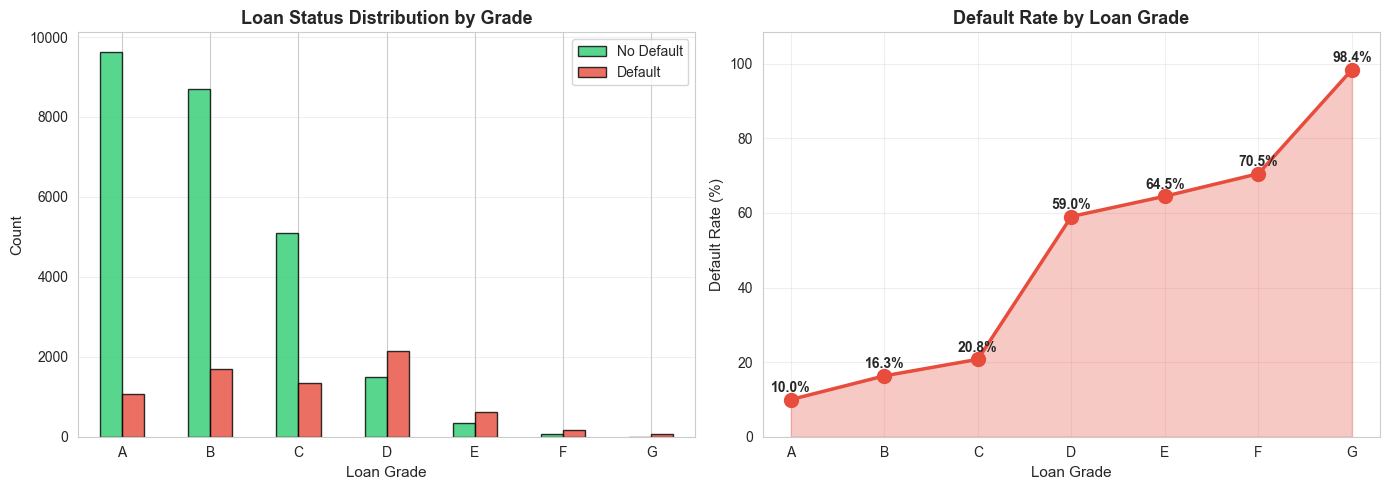

Default Rate by Loan Grade:
            default_rate
loan_grade              
A                   9.96
B                  16.32
C                  20.76
D                  59.05
E                  64.49
F                  70.54
G                  98.44


In [9]:
### Plot 2: Loan Grade as a Risk Proxy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loan grade count plot
loan_grade_counts = pd.crosstab(df_clean['loan_grade'], df_clean['loan_status'])
loan_grade_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'], alpha=0.8, edgecolor='black')
axes[0].set_title('Loan Status Distribution by Grade', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Grade', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].legend(['No Default', 'Default'], loc='upper right')
axes[0].grid(axis='y', alpha=0.3)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=0)

# Default rate by loan grade
default_rate_by_grade = df_clean.groupby('loan_grade')['loan_status'].agg(['sum', 'count'])
default_rate_by_grade['default_rate'] = (default_rate_by_grade['sum'] / default_rate_by_grade['count']) * 100
default_rate_by_grade = default_rate_by_grade.sort_index()

axes[1].plot(default_rate_by_grade.index, default_rate_by_grade['default_rate'], marker='o', linewidth=2.5, markersize=10, color='#e74c3c')
axes[1].fill_between(range(len(default_rate_by_grade)), default_rate_by_grade['default_rate'], alpha=0.3, color='#e74c3c')
axes[1].set_title('Default Rate by Loan Grade', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Loan Grade', fontsize=11)
axes[1].set_ylabel('Default Rate (%)', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, max(default_rate_by_grade['default_rate']) + 10)

for i, (grade, rate) in enumerate(zip(default_rate_by_grade.index, default_rate_by_grade['default_rate'])):
    axes[1].text(i, rate + 2, f'{rate:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Display detailed statistics
print("Default Rate by Loan Grade:")
print(default_rate_by_grade[['default_rate']].round(2))

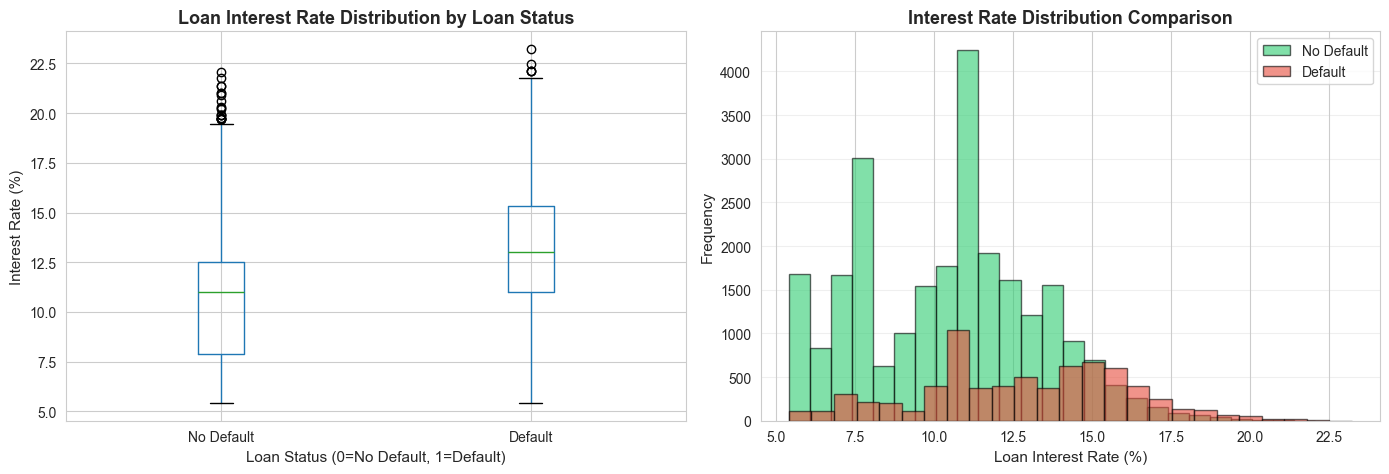

Interest Rate Statistics by Loan Status:
               count       mean       std   min    25%    50%    75%    max
loan_status                                                                
0            25321.0  10.492467  2.839694  5.42   7.88  10.99  12.53  22.06
1             7088.0  12.879454  3.194582  5.42  10.99  12.99  15.31  23.22

Median Interest Rate - No Default: 10.99%
Median Interest Rate - Default: 12.99%


In [10]:
### Plot 3: The Cost of Risk - Interest Rate and Defaults
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot for interest rate by loan status
df_clean.boxplot(column='loan_int_rate', by='loan_status', ax=axes[0])
axes[0].set_title('Loan Interest Rate Distribution by Loan Status', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Loan Status (0=No Default, 1=Default)', fontsize=11)
axes[0].set_ylabel('Interest Rate (%)', fontsize=11)
plt.sca(axes[0])
plt.xticks([1, 2], ['No Default', 'Default'])

# Histogram overlay
axes[1].hist(df_clean[df_clean['loan_status'] == 0]['loan_int_rate'], bins=25, alpha=0.6, label='No Default', color='#2ecc71', edgecolor='black')
axes[1].hist(df_clean[df_clean['loan_status'] == 1]['loan_int_rate'], bins=25, alpha=0.6, label='Default', color='#e74c3c', edgecolor='black')
axes[1].set_title('Interest Rate Distribution Comparison', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Loan Interest Rate (%)', fontsize=11)
axes[1].set_ylabel('Frequency', fontsize=11)
axes[1].legend(loc='upper right', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('')
plt.tight_layout()
plt.show()

# Interest rate statistics by default status
print("Interest Rate Statistics by Loan Status:")
int_rate_stats = df_clean.groupby('loan_status')['loan_int_rate'].describe()
print(int_rate_stats)
print(f"\nMedian Interest Rate - No Default: {df_clean[df_clean['loan_status'] == 0]['loan_int_rate'].median():.2f}%")
print(f"Median Interest Rate - Default: {df_clean[df_clean['loan_status'] == 1]['loan_int_rate'].median():.2f}%")

## 8. Summary: The 3 Most Interesting Patterns

### Pattern 1: Income as a Differentiator
**Key Finding:** There is a visible difference in the median annual income between the default and non-default groups. The default group (1) generally has a lower and tighter income distribution.

**Business Significance:** 
- Income is a foundational indicator of a borrower's capacity to repay.
- This confirms that lower-income individuals face higher financial strain, making income a vital feature for our predictive model.
- The IDSS should prioritize income assessment as a primary risk factor in loan approval decisions.

**Actionable Insight:** Borrowers with lower incomes pose higher default risk. The model should incorporate income thresholds and income-to-debt ratios in its risk scoring algorithm.

### Pattern 2: Loan Grade as a Risk Proxy
**Key Finding:** The proportion of defaults increases drastically as the loan grade descends from 'A' to 'G'. For grades F and G, the likelihood of default is exceptionally high.

**Business Significance:**
- The institution's existing internal grading system is already highly predictive of risk.
- Our IDSS model will leverage this heavily, but its true value will be finding the hidden risks in the borderline "middle" grades (B, C, and D) where human judgment is less certain.
- This indicates that the bank's existing risk assessment model is reasonably sound but may be missing nuances in mid-tier grades.

**Actionable Insight:** The model should strengthen its predictive power for middle-grade loans where there is more uncertainty. Additional features or ensemble methods should focus on improving discrimination between grades B, C, and D.

### Pattern 3: The Cost of Risk - Interest Rate and Default
**Key Finding:** Borrowers who defaulted generally had loans with significantly higher median interest rates.

**Business Significance:**
- While lenders charge higher interest rates to compensate for higher perceived risk, there is a compounding effect: the higher debt burden actively contributes to the borrower's inability to pay.
- This reveals a paradox in risk-based pricing: charging more for perceived risk can actually create the conditions for higher risk.
- The business needs to balance risk-based pricing with actual affordability to prevent a self-fulfilling prophecy of defaults.

**Actionable Insight:** The IDSS should flag cases where interest rates, combined with income levels, create unsustainable debt-to-income ratios. Consider implementing affordability checks that prevent loans with excessive interest rate burdens relative to the borrower's income, even if the risk grade appears acceptable.

## Conclusion: Phase 1 Complete

**Data Quality Actions Completed:**
✓ Removed 116 duplicate rows
✓ Imputed missing values in person_emp_length and loan_int_rate using median values
✓ Filtered impossible ages (> 100 years)
✓ Removed employment length outliers (> 60 years or > person's age)

**Dataset Ready for Phase 2 (Feature Engineering & Model Development):**
The cleaned dataset is now ready for:
- Feature engineering and selection
- Normalization/scaling of numerical features
- Encoding of categorical features
- Development of predictive models using the insights from this EDA

**Key Takeaways for Model Development:**
1. **Income** is a critical differentiator—include it prominently in feature engineering
2. **Loan Grade** is already predictive, but focus on improving discrimination in middle tiers (B, C, D)
3. **Interest Rate & Income Interaction** matters—consider interaction terms and debt-to-income ratios as features

## Phase 2: Data Preparation & Feature Engineering

In [11]:
# Phase 2 starts by isolating a holdout test set before any transformations.
# Business rationale: this protects the bank from leakage and gives a realistic estimate of how the policy will perform on future applicants.
target_col = 'loan_status'
feature_cols = [c for c in df_clean.columns if c != target_col]
X = df_clean[feature_cols].copy()
y = df_clean[target_col].copy()

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

split_summary = pd.DataFrame(
    {
        'Rows': [len(X_train_raw), len(X_test_raw)],
        'Default rate': [y_train.mean(), y_test.mean()]
    },
    index=['Train', 'Test']
)

display(split_summary)
print(f'Raw train shape: {X_train_raw.shape}')
print(f'Raw test shape: {X_test_raw.shape}')

,Rows,Default rate
Train,25927,0.218691
Test,6482,0.218760


Raw train shape: (25927, 11)
Raw test shape: (6482, 11)


### Train/Test Split — Business Rationale
The split is performed before any scaling, encoding, or engineered feature creation. This keeps the test set untouched and lets the bank measure how well the model generalizes to truly unseen applicants.

In [12]:
# Business-driven feature engineering after the split.
# Business rationale: these features compress repayment capacity and credit maturity into signals that are easier for underwriting to interpret consistently.
def add_business_features(frame: pd.DataFrame) -> pd.DataFrame:
    engineered = frame.copy()

    # Business rationale: credit-history length is more useful to the lender when grouped into interpretable maturity bands.
    engineered['credit_history_band'] = pd.cut(
        engineered['cb_person_cred_hist_length'],
        bins=[-np.inf, 3, 8, np.inf],
        labels=['Young', 'Established', 'Mature'],
        right=False,
        include_lowest=True
    ).astype('string')

    # Business rationale: combining loan grade with prior default history creates a compact severity signal that helps the bank prioritize riskier applications.
    grade_score = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
    prior_default_score = engineered['cb_person_default_on_file'].map({'N': 0, 'Y': 1})
    engineered['risk_severity_index'] = engineered['loan_grade'].map(grade_score).astype(float) + (prior_default_score.astype(float) * 2.0)

    return engineered

X_train_fe = add_business_features(X_train_raw)
X_test_fe = add_business_features(X_test_raw)

display(X_train_fe[[
    'cb_person_cred_hist_length',
    'credit_history_band',
    'loan_grade',
    'cb_person_default_on_file',
    'risk_severity_index'
]].head())

,cb_person_cred_hist_length,credit_history_band,loan_grade,cb_person_default_on_file,risk_severity_index
31277,16,Mature,B,N,2.0
5370,4,Established,E,N,5.0
13355,3,Established,B,N,2.0
31860,15,Mature,B,N,2.0
24203,6,Established,C,N,3.0


### Feature Engineering — Business Rationale
- `credit_history_band` gives the lender a simple maturity view of the borrower's credit history.
- `risk_severity_index` combines grade and prior default history to make the most policy-relevant risk signal more explicit.
- These features are created after the split so the holdout data remains untouched by training-time decisions.

In [13]:
# Reproducible preprocessing pipeline for model-ready matrices.
# Business rationale: scaling numeric variables prevents larger monetary fields from overpowering smaller behavioral features, while encoding preserves the meaning of ranked and nominal categories.
ordinal_cols = ['loan_grade', 'cb_person_default_on_file', 'credit_history_band']
ordinal_categories = [
    ['A', 'B', 'C', 'D', 'E', 'F', 'G'],
    ['N', 'Y'],
    ['Young', 'Established', 'Mature']
]
nominal_cols = ['person_home_ownership', 'loan_intent']
numeric_cols = [c for c in X_train_fe.columns if c not in ordinal_cols + nominal_cols]

numeric_pipeline = Pipeline(steps=[
    # Business rationale: median imputation preserves the applicant while avoiding distortions from extreme values.
    ('imputer', SimpleImputer(strategy='median')),
    # Business rationale: standard scaling puts all continuous features on the same scale so no single magnitude dominates the model.
    ('scaler', StandardScaler())
])

ordinal_pipeline = Pipeline(steps=[
    # Business rationale: mode imputation is a conservative fill for ranked fields when the bank has no observed value.
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # Business rationale: ordinal encoding preserves the natural risk order of grades, default history, and credit maturity.
    ('encoder', OrdinalEncoder(categories=ordinal_categories, handle_unknown='use_encoded_value', unknown_value=-1))
])

nominal_pipeline = Pipeline(steps=[
    # Business rationale: mode imputation keeps category fields usable without inventing risk information.
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # Business rationale: one-hot encoding avoids creating a false order for home ownership and loan purpose.
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_pipeline, numeric_cols),
        ('ord', ordinal_pipeline, ordinal_cols),
        ('nom', nominal_pipeline, nominal_cols)
    ],
    remainder='drop',
    verbose_feature_names_out=False
)

feature_prep_pipeline = Pipeline(steps=[
    ('feature_engineering', FunctionTransformer(add_business_features, validate=False)),
    ('preprocess', preprocessor)
])

X_train_processed_arr = feature_prep_pipeline.fit_transform(X_train_raw)
X_test_processed_arr = feature_prep_pipeline.transform(X_test_raw)
feature_names = feature_prep_pipeline.named_steps['preprocess'].get_feature_names_out()

X_train_processed = pd.DataFrame(X_train_processed_arr, columns=feature_names, index=X_train_raw.index)
X_test_processed = pd.DataFrame(X_test_processed_arr, columns=feature_names, index=X_test_raw.index)

prep_summary = pd.DataFrame(
    {
        'Rows': [len(X_train_processed), len(X_test_processed)],
        'Columns': [X_train_processed.shape[1], X_test_processed.shape[1]],
        'Missing values': [int(X_train_processed.isna().sum().sum()), int(X_test_processed.isna().sum().sum())]
    },
    index=['X_train_processed', 'X_test_processed']
)

display(prep_summary)
print('Processed feature sample:')
print(list(feature_names[:15]))
print(f'\nFinal matrix shapes:')
print(f'X_train_processed: {X_train_processed.shape}')
print(f'X_test_processed: {X_test_processed.shape}')

,Rows,Columns,Missing values
X_train_processed,25927,21,0
X_test_processed,6482,21,0


Processed feature sample:
['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'risk_severity_index', 'loan_grade', 'cb_person_default_on_file', 'credit_history_band', 'person_home_ownership_MORTGAGE', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT']

Final matrix shapes:
X_train_processed: (25927, 21)
X_test_processed: (6482, 21)


### Preprocessing Validation
The next cell confirms that the processed train and test matrices have the same feature space and no missing values, which is the minimum requirement before Phase 3 predictive modeling.

In [14]:
# Final Phase 2 validation for Phase 3 handoff.
# Business rationale: a concise audit trail helps the bank verify that the prepared matrices are leakage-safe and ready for model development.
validation_summary = pd.DataFrame(
    {
        'Rows': [len(X_train_processed), len(X_test_processed)],
        'Columns': [X_train_processed.shape[1], X_test_processed.shape[1]],
        'Target default rate': [y_train.mean(), y_test.mean()]
    },
    index=['X_train_processed', 'X_test_processed']
)

display(validation_summary)
print('\nX_train_processed preview:')
display(X_train_processed.head())
print('\nX_test_processed preview:')
display(X_test_processed.head())

,Rows,Columns,Target default rate
X_train_processed,25927,21,0.218691
X_test_processed,6482,21,0.218760



X_train_processed preview:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,risk_severity_index,loan_grade,cb_person_default_on_file,...,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
31277,1.510006,0.365413,3.587041,0.066435,-0.336807,-0.471326,2.526875,-0.340433,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5370,-0.436694,-0.300768,0.563333,-0.171904,1.514924,-0.002815,-0.443329,1.420621,4.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
13355,-0.274469,0.460581,-0.948522,1.655355,-0.012511,0.465695,-0.690846,-0.340433,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
31860,2.158905,0.436066,-0.696546,1.019787,-0.025483,0.090887,2.279358,-0.340433,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
24203,1.185556,-0.510139,-0.696546,0.066435,0.691212,0.840504,0.051705,0.246585,2.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0



X_test_processed preview:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,risk_severity_index,loan_grade,cb_person_default_on_file,...,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
16636,-0.923369,-0.434080,-0.444570,-0.759804,0.000461,-0.565028,-0.443329,1.420621,2.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
26980,0.536656,0.803189,1.571235,4.038737,0.798230,1.402717,1.041773,0.246585,2.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
19849,0.374431,-0.453038,0.059381,0.225327,-0.216818,0.840504,1.041773,-0.340433,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
24183,0.536656,-0.395936,-0.192595,0.066435,-0.122772,0.465695,-0.195812,-0.340433,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
25071,1.023331,-0.673600,-0.192595,0.384219,-0.210332,2.058632,-0.195812,-0.340433,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


## Conclusion: Phase 2 Complete

Phase 2 now isolates the test set before any transformation, then uses a scikit-learn pipeline to impute, engineer, ordinal-encode, one-hot encode, and scale the features in a leakage-safe way. The engineered `credit_history_band` and `risk_severity_index` add underwriting-friendly risk signals, while the final `X_train_processed` and `X_test_processed` matrices are aligned, fully numeric, and ready for Phase 3 predictive modeling.

# Phase 2: Feature Engineering & Preprocessing

## Feature: loan_to_income_ratio
This feature is defined as loan amount divided by borrower income. It quantifies borrower capacity and helps detect over-leveraging: higher values indicate the borrower is taking on a larger loan relative to income, which raises default risk.

In [15]:
# Create loan_to_income_ratio on df_clean (safe to run in this notebook context)
import numpy as np
# prefer existing column names used earlier in the notebook
loan_col = 'loan_amnt' if 'loan_amnt' in df_clean.columns else ( 'loan_amnt' )
income_col = 'person_income' if 'person_income' in df_clean.columns else ('person_income')
# safe creation (avoid division by zero)
df_clean['loan_to_income_ratio'] = df_clean[loan_col] / df_clean[income_col].replace({0:np.nan})
df_clean['loan_to_income_ratio'] = df_clean['loan_to_income_ratio'].fillna(0)
print('loan_to_income_ratio created; sample:')
display(df_clean[['loan_to_income_ratio']].head())

loan_to_income_ratio created; sample:


,loan_to_income_ratio
1,0.104167
2,0.572917
3,0.534351
4,0.643382
5,0.252525


## Feature: emp_length_to_age_ratio
This feature is employment length divided by borrower age. It serves as a proxy for career stability and historical reliability: higher ratios suggest longer tenure relative to age (consistent employment), which can indicate lower behavioral risk.

In [16]:
# Create emp_length_to_age_ratio using existing columns if present
def parse_emp_length(x):
    import numpy as _np
    if pd.isna(x):
        return _np.nan
    if isinstance(x, (int, float)):
        return float(x)
    s = str(x).strip().lower()
    if s in ['n/a','nan','unknown','none','']:
        return _np.nan
    if '<' in s:
        digits = ''.join(ch for ch in s if ch.isdigit())
        return float(digits) if digits else 0.5
    digits = ''.join(ch for ch in s if ch.isdigit())
    try:
        return float(digits) if digits else _np.nan
    except:
        return _np.nan
# use columns created/cleaned earlier
emp_col = 'person_emp_length' if 'person_emp_length' in df_clean.columns else None
age_col = 'person_age' if 'person_age' in df_clean.columns else None
if emp_col is not None:
    df_clean['emp_length_parsed'] = df_clean[emp_col].apply(parse_emp_length)
else:
    df_clean['emp_length_parsed'] = np.nan
if age_col is not None:
    df_clean['age_parsed'] = pd.to_numeric(df_clean[age_col], errors='coerce')
else:
    df_clean['age_parsed'] = np.nan
df_clean['emp_length_to_age_ratio'] = df_clean['emp_length_parsed'] / df_clean['age_parsed'].replace({0:np.nan})
df_clean['emp_length_to_age_ratio'] = df_clean['emp_length_to_age_ratio'].fillna(0)
print('emp_length_to_age_ratio created; sample:')
display(df_clean[['emp_length_parsed','age_parsed','emp_length_to_age_ratio']].head())

emp_length_to_age_ratio created; sample:


,emp_length_parsed,age_parsed,emp_length_to_age_ratio
1,5.0,21,0.238095
2,1.0,25,0.040000
3,4.0,23,0.173913
4,8.0,24,0.333333
5,2.0,21,0.095238


## Risk Flag: high_risk_profile
Create a binary flag set to 1 when previous default is 'Y' AND interest rate > 14%, else 0. This heuristic highlights profiles with both demonstrated past default and relatively high-cost credit, which together indicate materially elevated risk.

In [17]:
# Create high_risk_profile using df_clean columns
def parse_interest(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        s = x.strip().replace('%','')
        try:
            return float(s)
        except:
            return np.nan
    try:
        return float(x)
    except:
        return np.nan
if 'loan_int_rate' in df_clean.columns:
    df_clean['_int_rate_numeric'] = df_clean['loan_int_rate'].apply(parse_interest)
else:
    df_clean['_int_rate_numeric'] = np.nan
if 'cb_person_default_on_file' in df_clean.columns:
    df_clean['_prev_default_flag'] = df_clean['cb_person_default_on_file'].astype(str).str.strip().str.upper().replace({'YES':'Y','NO':'N','TRUE':'Y','FALSE':'N'})
else:
    df_clean['_prev_default_flag'] = 'N'
df_clean['high_risk_profile'] = ((df_clean['_prev_default_flag'] == 'Y') & (df_clean['_int_rate_numeric'] > 14)).astype(int)
print('high_risk_profile distribution:')
print(df_clean['high_risk_profile'].value_counts(dropna=False))

high_risk_profile distribution:


high_risk_profile
0    29576
1     2833
Name: count, dtype: int64


## Categorical Encoding Decisions
We map `loan_grade` ordinally (A→7 ... G→1) because higher grades indicate lower risk; `cb_person_default_on_file` is mapped to binary to capture past default presence; `person_home_ownership` and `loan_intent` are one-hot encoded to convert business contexts (renting vs owning, debt consolidation vs small business loan) into model-friendly numeric distances that models use to learn differential risk patterns.

In [18]:
# Categorical encoding on df_clean (create a working copy df_phase2)
df_phase2 = df_clean.copy()
grade_map = {'A':7,'B':6,'C':5,'D':4,'E':3,'F':2,'G':1}
if 'loan_grade' in df_phase2.columns:
    df_phase2['loan_grade_mapped'] = df_phase2['loan_grade'].astype(str).str.strip().str.upper().map(grade_map)
else:
    df_phase2['loan_grade_mapped'] = np.nan
if 'cb_person_default_on_file' in df_phase2.columns:
    df_phase2['cb_person_default_on_file_bin'] = df_phase2['cb_person_default_on_file'].astype(str).str.strip().str.upper().map({'Y':1,'N':0})
else:
    df_phase2['cb_person_default_on_file_bin'] = 0
ohe_cols = [c for c in ['person_home_ownership','loan_intent'] if c in df_phase2.columns]
if ohe_cols:
    df_phase2 = pd.get_dummies(df_phase2, columns=ohe_cols, drop_first=True)
    print('One-hot encoded:', ohe_cols)
else:
    print('No columns found for one-hot encoding.')
display(df_phase2.head())

One-hot encoded: ['person_home_ownership', 'loan_intent']


,person_age,person_income,person_emp_length,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,...,loan_grade_mapped,cb_person_default_on_file_bin,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
1,21,9600,5.0,B,1000,11.14,0,0.10,N,2,...,6,0,False,True,False,True,False,False,False,False
2,25,9600,1.0,C,5500,12.87,1,0.57,N,3,...,5,0,False,False,False,False,False,True,False,False
3,23,65500,4.0,C,35000,15.23,1,0.53,N,2,...,5,0,False,False,True,False,False,True,False,False
4,24,54400,8.0,C,35000,14.27,1,0.55,Y,4,...,5,1,False,False,True,False,False,True,False,False
5,21,9900,2.0,A,2500,7.14,1,0.25,N,2,...,7,0,False,True,False,False,False,False,False,True


## Feature Scaling Rationale
Scaling continuous financial features (age, income, loan amount, interest rate, credit history length, and the new ratio features) prevents any single metric with large magnitude or skew from dominating distance-based or gradient-based algorithms. RobustScaler handles outliers well for financial distributions; StandardScaler is an alternative when distributions are approximately symmetric.

In [19]:
# Feature scaling using RobustScaler on df_phase2
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
numeric_candidates = ['person_age','person_income','loan_amnt','loan_int_rate','cb_person_cred_hist_length','loan_to_income_ratio','emp_length_to_age_ratio']
scale_cols = [c for c in numeric_candidates if c in df_phase2.columns]
print('Columns to scale:', scale_cols)
if scale_cols:
    scaled_vals = scaler.fit_transform(df_phase2[scale_cols].fillna(0))
    for i, col in enumerate(scale_cols):
        df_phase2[f'{col}_scaled'] = scaled_vals[:, i]
    print('Scaling applied. Sample:')
    display(df_phase2[[f for f in df_phase2.columns if f.endswith('_scaled')]].head())
else:
    print('No numeric columns found to scale.')

Columns to scale: ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'cb_person_cred_hist_length', 'loan_to_income_ratio', 'emp_length_to_age_ratio']
Scaling applied. Sample:


,person_age_scaled,person_income_scaled,loan_amnt_scaled,loan_int_rate_scaled,cb_person_cred_hist_length_scaled,loan_to_income_ratio_scaled,emp_length_to_age_ratio_scaled
1,-0.714286,-1.115479,-0.965517,0.032468,-0.4,-0.315405,0.436508
2,-0.142857,-1.115479,-0.344828,0.406926,-0.2,3.046151,-0.524837
3,-0.428571,0.257985,3.724138,0.917749,-0.4,2.769585,0.125036
4,-0.285714,-0.014742,3.724138,0.709957,0.0,3.551483,0.898693
5,-0.714286,-1.108108,-0.758621,-0.833333,-0.4,0.748522,-0.256769


## Reproducible Pipeline & Save Output
The final preprocessed dataframe is saved as `credit_risk_phase2_ready.csv` for Phase 3. This CSV contains engineered features, encoded categorical variables, and scaled numeric columns, enabling reproducible downstream modeling.

In [20]:
# Save preprocessed dataframe
out_path = 'credit_risk_phase2_ready.csv'
save_cols = [col for col in ['loan_to_income_ratio','emp_length_to_age_ratio','high_risk_profile','loan_grade_mapped','cb_person_default_on_file_bin'] if col in df_phase2.columns]
save_cols += [c for c in df_phase2.columns if c.endswith('_scaled') and c not in save_cols]
if not save_cols:
    df_phase2.to_csv(out_path, index=False)
else:
    df_phase2[save_cols].to_csv(out_path, index=False)
print(f'Saved preprocessed data to {out_path}')
print('Saved columns:', save_cols if save_cols else 'full dataframe saved')

Saved preprocessed data to credit_risk_phase2_ready.csv
Saved columns: ['loan_to_income_ratio', 'emp_length_to_age_ratio', 'high_risk_profile', 'loan_grade_mapped', 'cb_person_default_on_file_bin', 'person_age_scaled', 'person_income_scaled', 'loan_amnt_scaled', 'loan_int_rate_scaled', 'cb_person_cred_hist_length_scaled', 'loan_to_income_ratio_scaled', 'emp_length_to_age_ratio_scaled']


**Phase 2 complete.** The file `credit_risk_phase2_ready.csv` is produced and ready for Phase 3 modeling.